# **CSL2050: Pattern Recognition and Machine Learning**
## **Course Project: Hand-drawn Sketch Recognition**

### **Step 1:** Importing the dataset

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

# Define paths
zip_path = "/content/Dataset_PNG.zip"  # Change this if needed
extract_path = "/content/Dataset_PNG"  # Folder where dataset will be extracted

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify extraction
os.listdir(extract_path)  # Should show "png" folder inside

['sketches_png']

In [4]:
dataset_path = "/content/Dataset_PNG/sketches_png/png"

# Check the extracted dataset folder
print(os.listdir(dataset_path))  # Should show category folders like 'zebra', 'cat', etc.

# Check some images inside a category
sample_category = os.path.join(dataset_path, "zebra")  # Change to any category name
print(os.listdir(sample_category)[:5])  # List first 5 images

['radio', 'pretzel', 'wheelbarrow', 'mailbox', 'purse', 'tooth', 'ipod', 'toilet', 'satellite dish', 'parrot', 'sheep', 'frog', 'stapler', 'shovel', 'space shuttle', 'floor lamp', 'hammer', 'beer-mug', 'angel', 'backpack', 'bush', 'truck', 'motorbike', 'butterfly', 'rainbow', 'basket', 'arm', 'tomato', 'vase', 'tree', 'dog', 'door', 'cigarette', 'bench', 'flashlight', 'squirrel', 'trousers', 'hat', 'giraffe', 'head', 'train', 'wrist-watch', 'donut', 'head-phones', 'potted plant', 'fork', 'elephant', 'spider', 'bottle opener', 'candle', 'ant', 'binoculars', 'dolphin', 'hot air balloon', 'bed', 'sword', 'windmill', 'helmet', 'pipe (for smoking)', 'violin', 'rifle', 'sponge bob', 'computer-mouse', 'owl', 'spoon', 'bicycle', 'snail', 'ashtray', 'rooster', 'teacup', 'monkey', 'eye', 'swan', 'shark', 'calculator', 'fan', 'ship', 'computer monitor', 'fish', 'mushroom', 'bee', 'axe', 'airplane', 'hand', 'crane (machine)', 'hedgehog', 'toothbrush', 'nose', 'diamond', 'feather', 'microscope', 'w

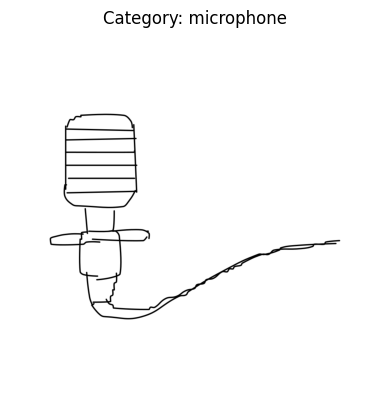

In [5]:
import cv2
import matplotlib.pyplot as plt
import random

# Pick a random category
categories = os.listdir(dataset_path)
random_category = random.choice(categories)

# Pick a random image from the category
image_folder = os.path.join(dataset_path, random_category)
image_name = random.choice(os.listdir(image_folder))
image_path = os.path.join(image_folder, image_name)

# Load and display the image
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
plt.imshow(image, cmap='gray')
plt.title(f"Category: {random_category}")
plt.axis("off")
plt.show()

In [8]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from skimage.feature import hog, local_binary_pattern
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import cv2

# Enhanced feature extraction
# Enhanced feature extraction
def extract_features(img):
    # HOG features
    hog_feat = hog(img, orientations=9, pixels_per_cell=(16,16),
                  cells_per_block=(2,2), block_norm='L2-Hys')

    # LBP features (complements HOG well for sketches)
    lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
    lbp_hist = np.histogram(lbp, bins=10, range=(0,10))[0]

    # Simple shape features
    # Convert image to uint8 before applying Canny
    img_uint8 = (img * 255).astype(np.uint8)
    edges = cv2.Canny(img_uint8, 100, 200)
    edge_density = np.mean(edges)/255

    return np.concatenate([hog_feat, lbp_hist, [edge_density]])

# Load data with enhanced features
def load_enhanced_features(dataset_path, max_samples=100):
    categories = os.listdir(dataset_path)
    X, y = [], []

    for category in tqdm(categories):
        cat_path = os.path.join(dataset_path, category)
        samples = 0

        for img_name in os.listdir(cat_path)[:max_samples]:
            img_path = os.path.join(cat_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (128,128))
            img = img / 255.0  # Normalize

            # Extract enhanced features
            features = extract_features(img)
            X.append(features)
            y.append(category)
            samples += 1

            if samples >= max_samples:
                break

    return np.array(X), np.array(y)

# Load data with enhanced features
X, y = load_enhanced_features(dataset_path, max_samples=100)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale features (MinMax works better than StandardScaler for this)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optimized KNN model
best_knn = KNeighborsClassifier(
    n_neighbors=15,  # Slightly larger k for stability
    weights='distance',
    metric='manhattan',  # Better for high-dim data
    algorithm='ball_tree',  # Better for high dimensions
    n_jobs=-1
)

best_knn.fit(X_train_scaled, y_train)

# Evaluation
y_pred = best_knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Improved Accuracy: {accuracy:.4f}")

# Classification report for imbalanced classes
print("\nBalanced Accuracy Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

  0%|          | 0/250 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
100%|██████████| 250/250 [03:12<00:00,  1.30it/s]


Improved Accuracy: 0.2782

Balanced Accuracy Report:
                    precision    recall  f1-score   support

          airplane       0.25      0.25      0.25        16
       alarm clock       0.33      0.12      0.18        16
             angel       1.00      0.12      0.22        16
               ant       0.00      0.00      0.00        16
             apple       0.67      0.75      0.71        16
               arm       0.29      0.25      0.27        16
          armchair       0.29      0.12      0.17        16
           ashtray       0.18      0.12      0.15        16
               axe       0.27      0.25      0.26        16
          backpack       0.33      0.06      0.11        16
            banana       0.50      0.38      0.43        16
              barn       0.43      0.19      0.26        16
      baseball bat       0.26      0.38      0.31        16
            basket       0.11      0.19      0.14        16
           bathtub       0.07      0.06      0